In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [4]:
df.info

<bound method DataFrame.info of       Time        V1        V2        V3        V4        V5        V6  \
0        0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388   
1        0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361   
2        1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499   
3        1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203   
4        2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921   
...    ...       ...       ...       ...       ...       ...       ...   
4408  3767  1.412385 -0.665603 -0.908695 -1.620974  1.463905  3.272691   
4409  3767  1.445452 -0.542984  0.062161 -0.818044 -0.322859  0.232912   
4410  3767  1.458499 -0.589402 -0.881930 -1.640364  1.487446  3.264101   
4411  3767  1.234772 -0.516604  0.672130 -0.597005 -0.788783 -0.177225   
4412  3767  1.442561 -0.615738 -0.000000       NaN       NaN       NaN   

            V7        V8        V9  ...       V21       V22       V23  \
0     

In [5]:
df.shape

(4413, 31)

In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        1
V5        1
V6        1
V7        1
V8        1
V9        1
V10       1
V11       1
V12       1
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64

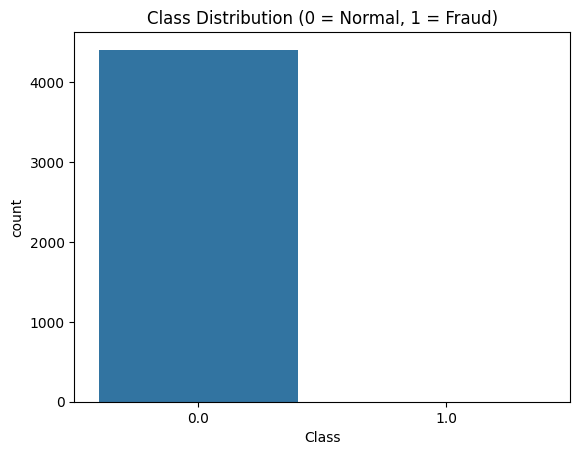

In [7]:
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()

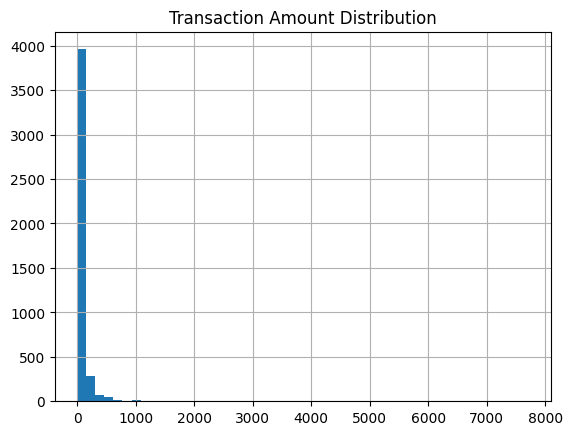

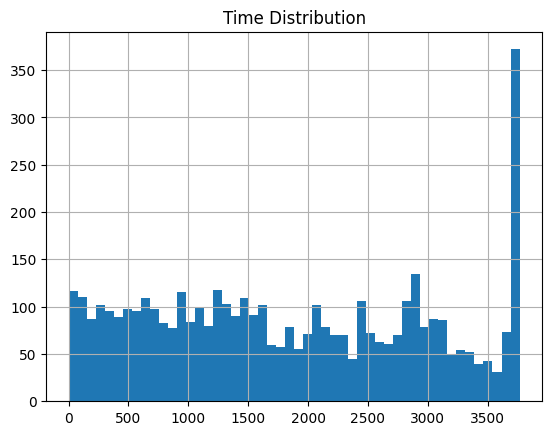

In [8]:
df['Amount'].hist(bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

df['Time'].hist(bins=50)
plt.title("Time Distribution")
plt.show()

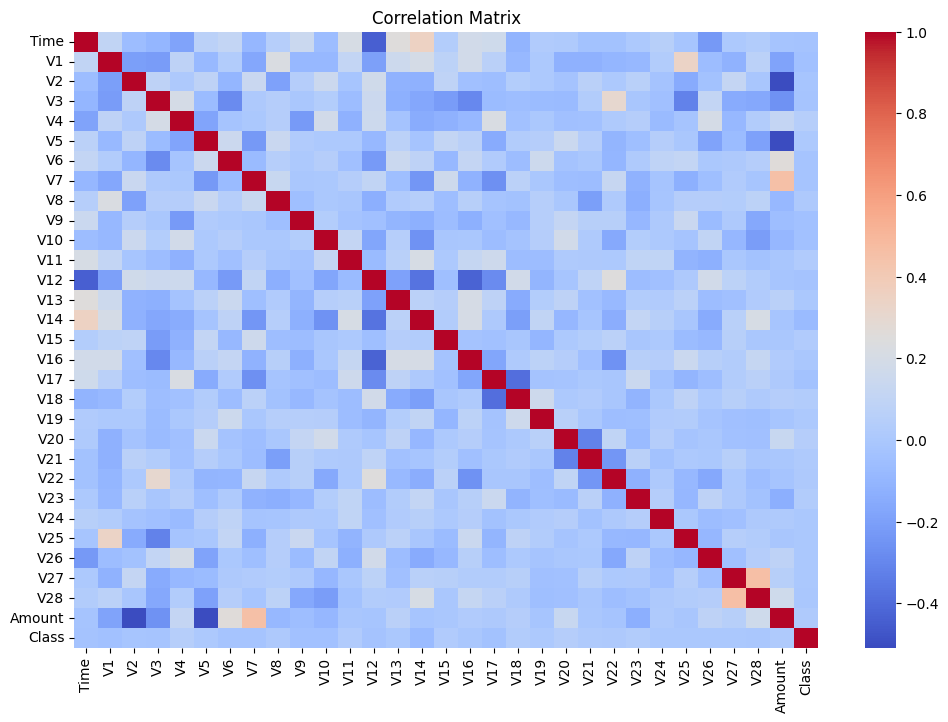

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

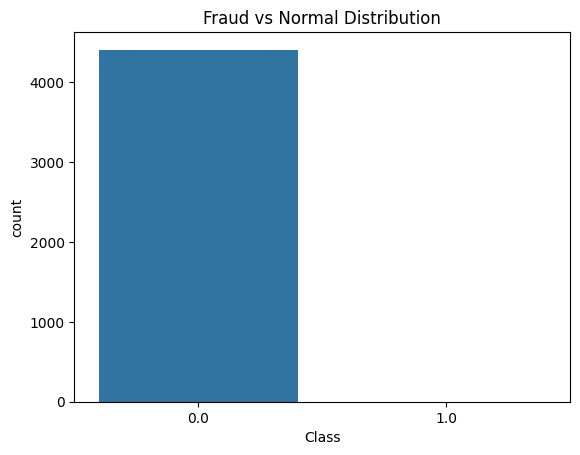

In [18]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Distribution")
plt.show()

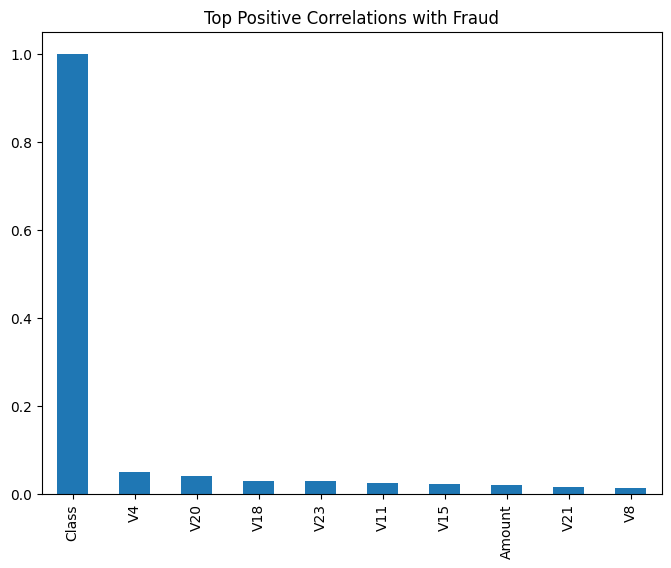

In [20]:
corr = df.corr()['Class'].sort_values(ascending=False)

plt.figure(figsize=(8,6))
corr.head(10).plot(kind='bar')
plt.title("Top Positive Correlations with Fraud")
plt.show()

In [10]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

In [13]:
df = df.dropna(subset=['Class'])

In [14]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

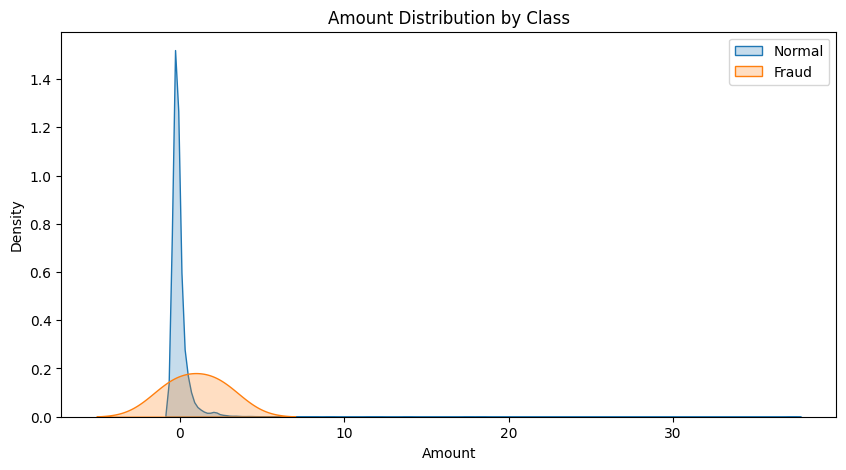

In [19]:
plt.figure(figsize=(10,5))
sns.kdeplot(df[df['Class']==0]['Amount'], label='Normal', fill=True)
sns.kdeplot(df[df['Class']==1]['Amount'], label='Fraud', fill=True)
plt.legend()
plt.title("Amount Distribution by Class")
plt.show()

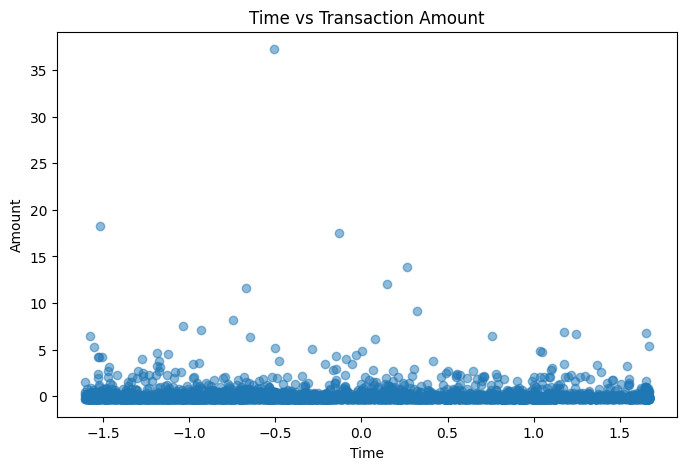

In [40]:
plt.figure(figsize=(8,5))
plt.scatter(df['Time'], df['Amount'], alpha=0.5)
plt.title("Time vs Transaction Amount")
plt.xlabel("Time")
plt.ylabel("Amount")
plt.show()

C:\Users\Parth\AppData\Local\Temp\ipykernel_52264\305541793.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_amount'] = np.log1p(df['Amount'])


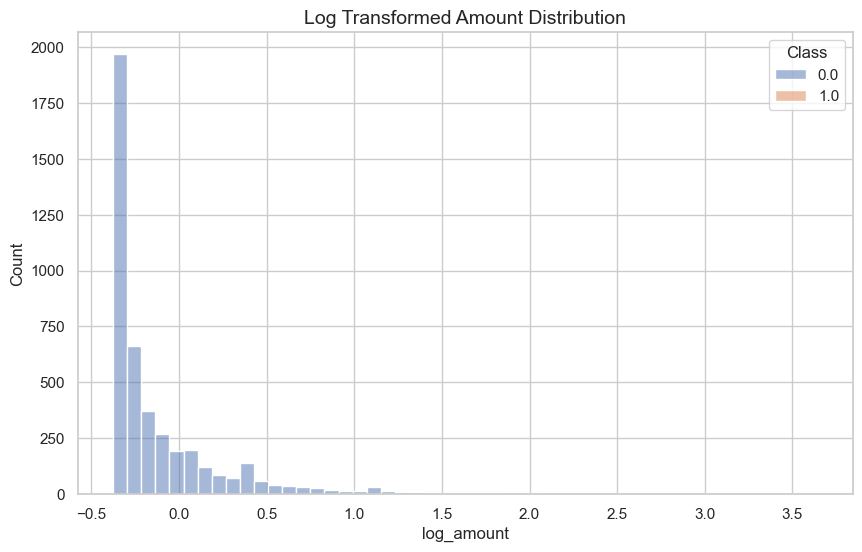

In [54]:

df['log_amount'] = np.log1p(df['Amount'])

sns.histplot(data=df, x='log_amount', hue='Class', bins=50)
plt.title("Log Transformed Amount Distribution")
plt.show()

In [15]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print("Logistic Regression Results:")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression Results:
[[882   1]
 [  0   0]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       883
         1.0       0.00      0.00      0.00         0

    accuracy                           1.00       883
   macro avg       0.50      0.50      0.50       883
weighted avg       1.00      1.00      1.00       883

ROC AUC: nan


C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [16]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Random Forest Results:")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest Results:
[[883]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       883

    accuracy                           1.00       883
   macro avg       1.00      1.00      1.00       883
weighted avg       1.00      1.00      1.00       883

ROC AUC: nan


C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [17]:
print("LR ROC AUC:", roc_auc_score(y_test, y_prob_lr))
print("RF ROC AUC:", roc_auc_score(y_test, y_prob_rf))

LR ROC AUC: nan
RF ROC AUC: nan


C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [24]:
!pip install xgboost catboost imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]




[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['Amount','Time']] = scaler.fit_transform(df[['Amount','Time']])

C:\Users\Parth\AppData\Local\Temp\ipykernel_52264\1556162156.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['Amount','Time']] = scaler.fit_transform(df[['Amount','Time']])


In [32]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(k_neighbors=1, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

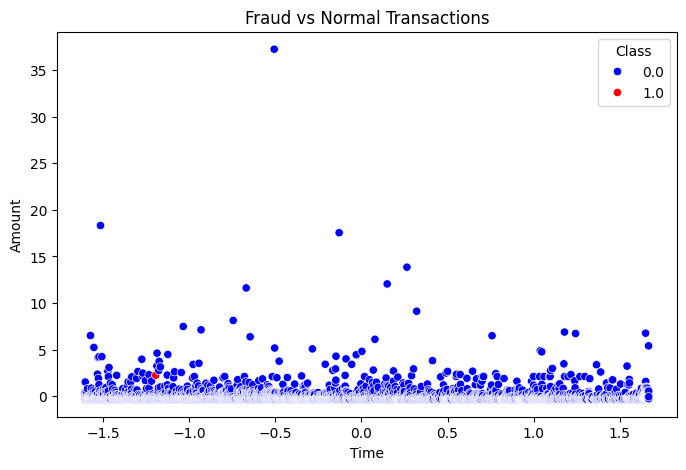

In [41]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Time',
    y='Amount',
    hue='Class',
    data=df,
    palette=['blue', 'red']
)

plt.title("Fraud vs Normal Transactions")
plt.show()

In [35]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=10,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_sm, y_train_sm)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

XGBoost Results:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       883
         1.0       0.00      0.00      0.00         0

    accuracy                           1.00       883
   macro avg       0.50      0.50      0.50       883
weighted avg       1.00      1.00      1.00       883

ROC AUC: nan


C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [36]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    verbose=0
)

cat.fit(X_train_sm, y_train_sm)

y_pred_cat = cat.predict(X_test)
y_prob_cat = cat.predict_proba(X_test)[:,1]

print("CatBoost Results:")
print(classification_report(y_test, y_pred_cat))
print("ROC AUC:", roc_auc_score(y_test, y_prob_cat))

CatBoost Results:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       883
         1.0       0.00      0.00      0.00         0

    accuracy                           1.00       883
   macro avg       0.50      0.50      0.50       883
weighted avg       1.00      1.00      1.00       883

ROC AUC: nan


C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [38]:
fraud_df = df[df['Class'] == 1]
normal_df = df[df['Class'] == 0]

# Keep 1 fraud in test
fraud_train = fraud_df.iloc[:1]
fraud_test = fraud_df.iloc[1:]

# Split normal data
from sklearn.model_selection import train_test_split
normal_train, normal_test = train_test_split(normal_df, test_size=0.2, random_state=42)

train_df = pd.concat([normal_train, fraud_train])
test_df = pd.concat([normal_test, fraud_test])

X_train = train_df.drop('Class', axis=1)
y_train = train_df['Class']

X_test = test_df.drop('Class', axis=1)
y_test = test_df['Class']

In [39]:
print("XGBoost ROC AUC:", roc_auc_score(y_test, y_prob_xgb))
print("CatBoost ROC AUC:", roc_auc_score(y_test, y_prob_cat))

XGBoost ROC AUC: 0.753968253968254
CatBoost ROC AUC: 0.63718820861678


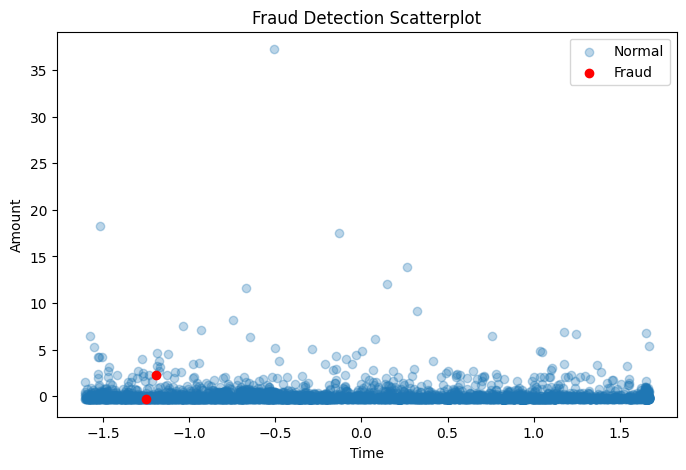

In [42]:
plt.figure(figsize=(8,5))

plt.scatter(
    df[df['Class']==0]['Time'],
    df[df['Class']==0]['Amount'],
    alpha=0.3,
    label='Normal'
)

plt.scatter(
    df[df['Class']==1]['Time'],
    df[df['Class']==1]['Amount'],
    color='red',
    label='Fraud'
)

plt.legend()
plt.title("Fraud Detection Scatterplot")
plt.xlabel("Time")
plt.ylabel("Amount")
plt.show()

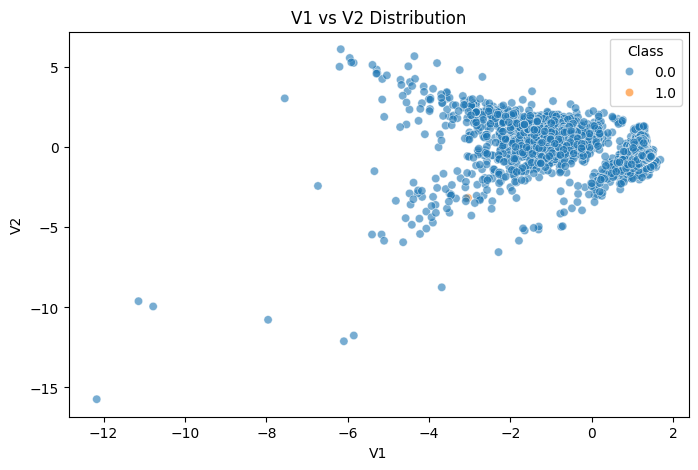

In [43]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='V1',
    y='V2',
    hue='Class',
    data=df,
    alpha=0.6
)

plt.title("V1 vs V2 Distribution")
plt.show()

In [44]:

plt.style.use('default')
sns.set_theme(style="whitegrid")

plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

C:\Users\Parth\AppData\Local\Temp\ipykernel_52264\1880227197.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['#4CAF50','#F44336'])


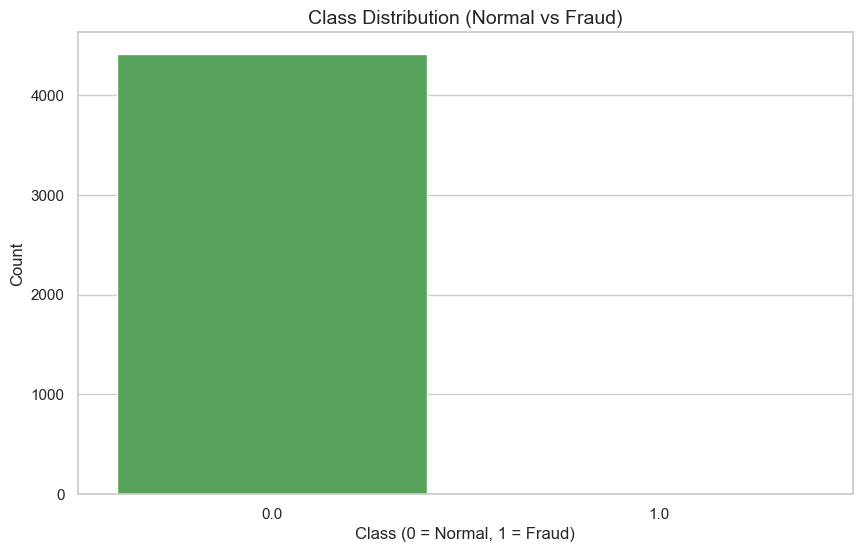

In [45]:
sns.countplot(x='Class', data=df, palette=['#4CAF50','#F44336'])
plt.title("Class Distribution (Normal vs Fraud)")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

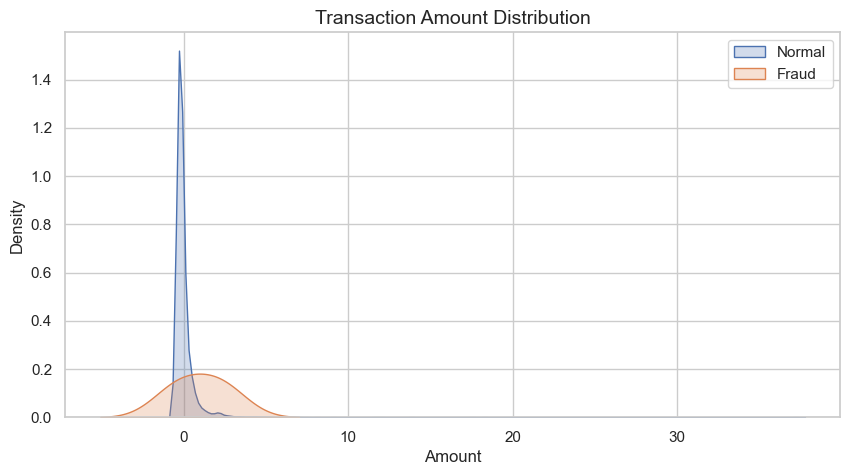

In [46]:
plt.figure(figsize=(10,5))

sns.kdeplot(df[df['Class']==0]['Amount'], label='Normal', fill=True)
sns.kdeplot(df[df['Class']==1]['Amount'], label='Fraud', fill=True)

plt.title("Transaction Amount Distribution")
plt.legend()
plt.show()

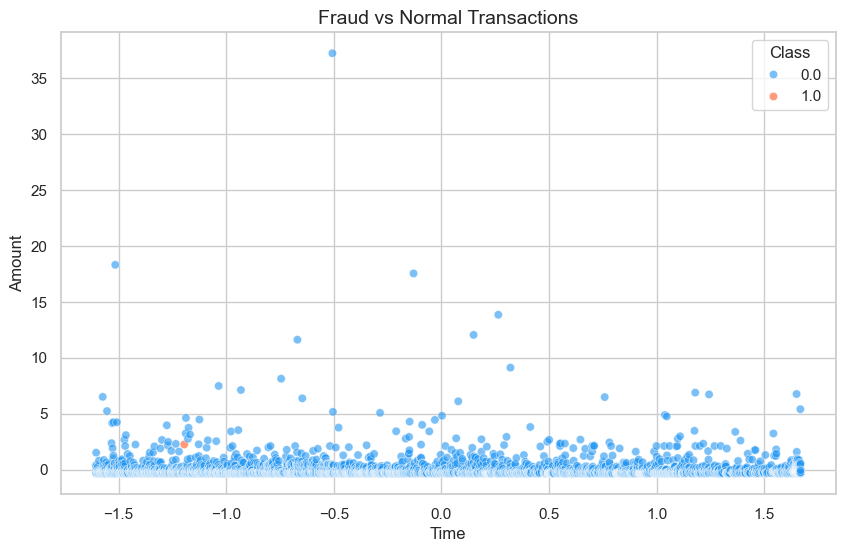

In [47]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Time',
    y='Amount',
    hue='Class',
    data=df,
    palette=['#2196F3','#FF5722'],
    alpha=0.6
)

plt.title("Fraud vs Normal Transactions")
plt.show()

C:\Users\Parth\AppData\Local\Temp\ipykernel_52264\602235657.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


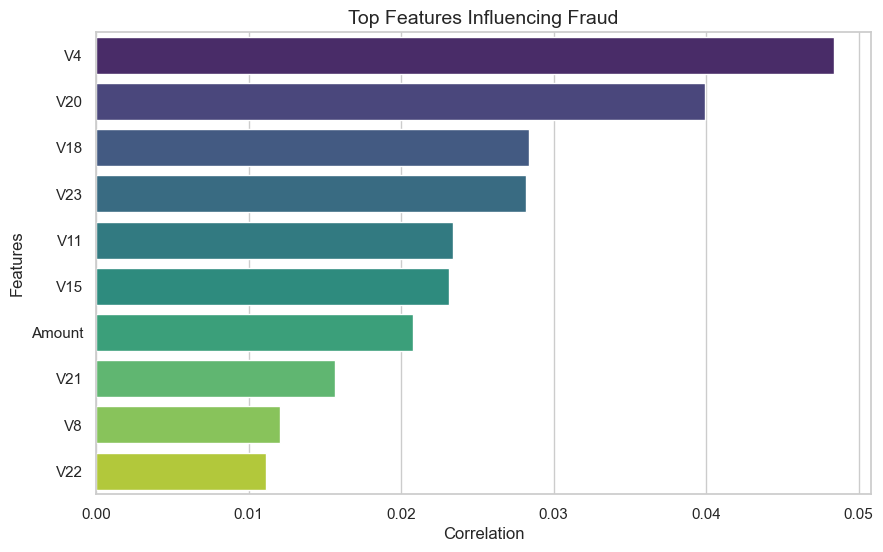

In [48]:
corr = df.corr()['Class'].sort_values(ascending=False)

top_features = corr[1:11]

sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title("Top Features Influencing Fraud")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.show()

C:\Users\Parth\AppData\Local\Temp\ipykernel_52264\2205863069.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, palette=['#4CAF50','#F44336'])


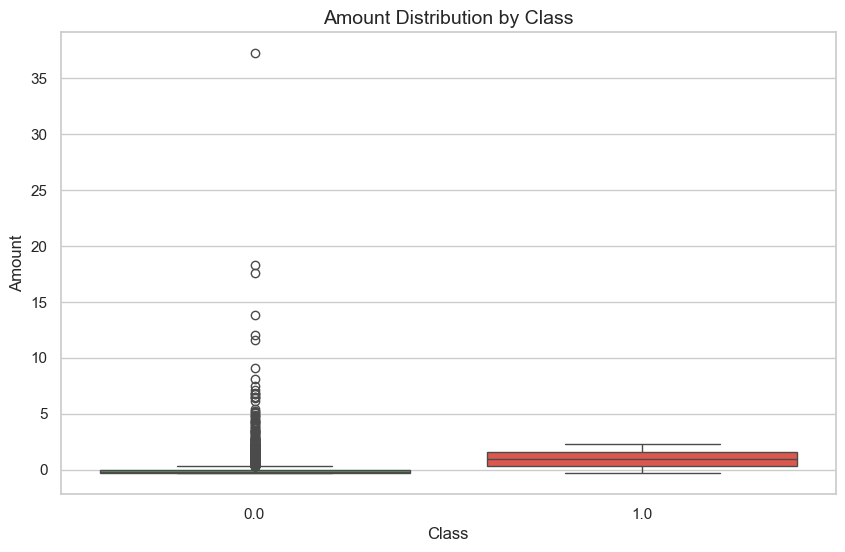

In [49]:
sns.boxplot(x='Class', y='Amount', data=df, palette=['#4CAF50','#F44336'])
plt.title("Amount Distribution by Class")
plt.show()

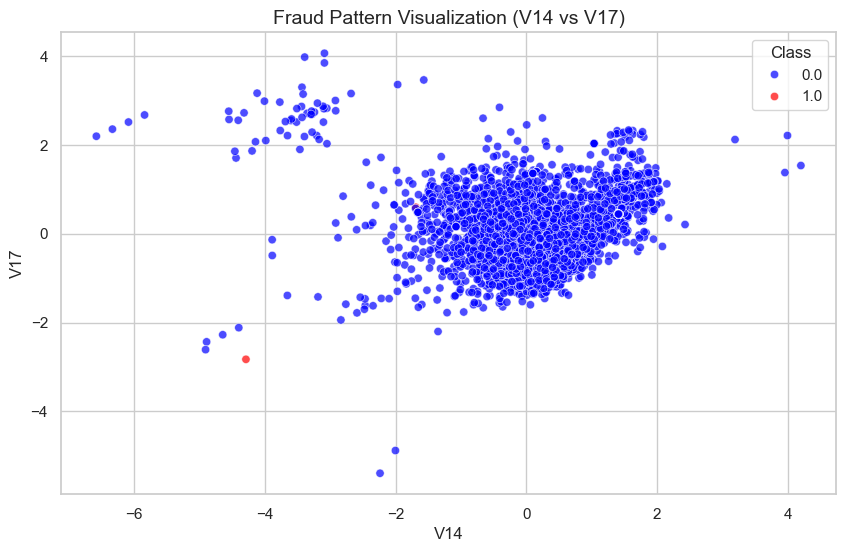

In [50]:
sns.scatterplot(
    x='V14',
    y='V17',
    hue='Class',
    data=df,
    alpha=0.7,
    palette=['blue','red']
)

plt.title("Fraud Pattern Visualization (V14 vs V17)")
plt.show()

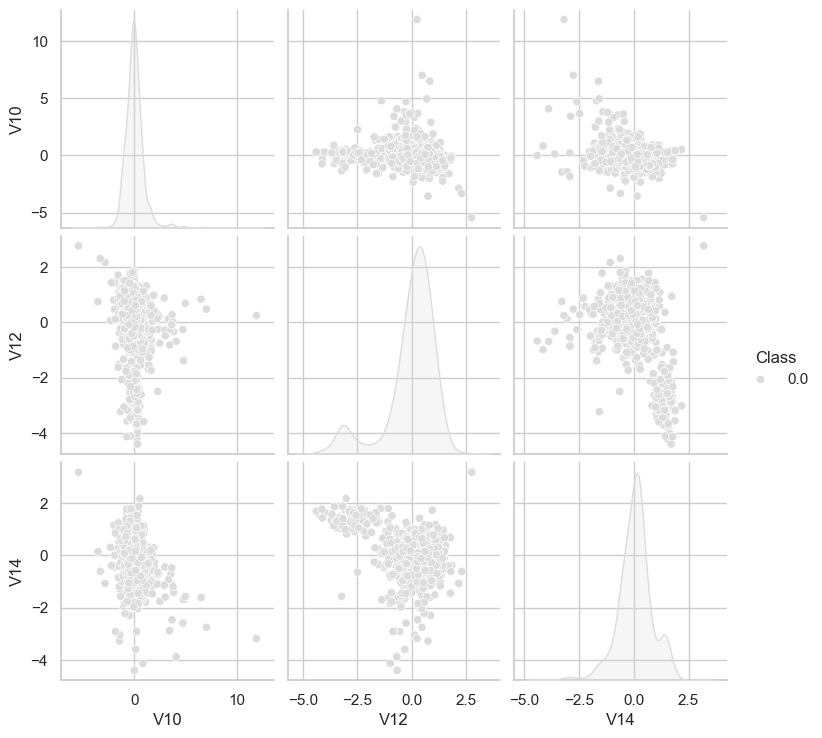

In [51]:
sample_df = df.sample(1000, random_state=42)

sns.pairplot(
    sample_df[['V10','V12','V14','Class']],
    hue='Class',
    palette='coolwarm'
)

plt.show()

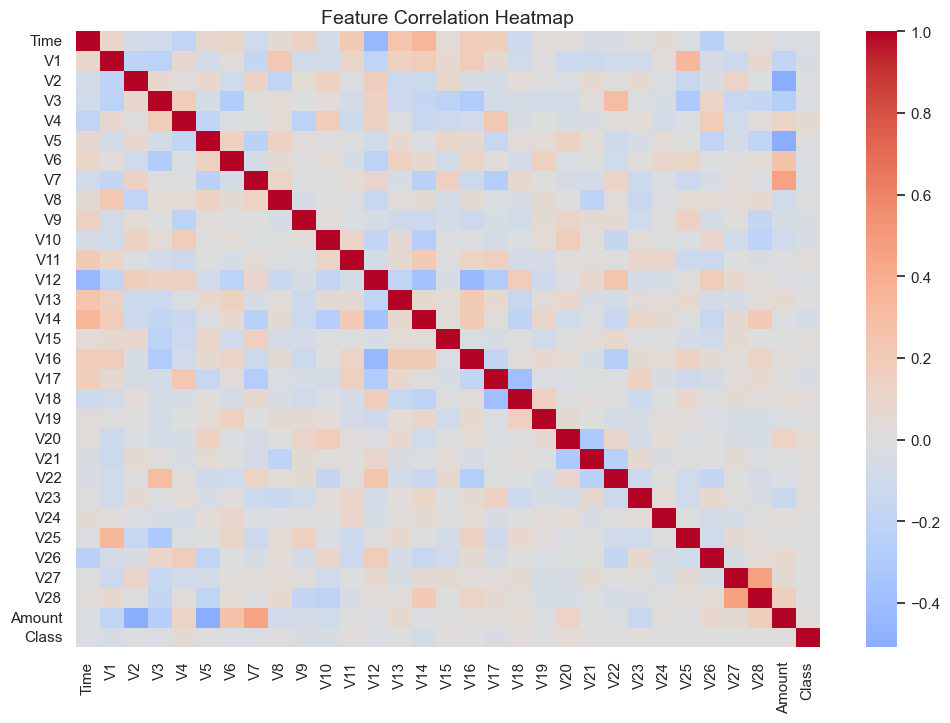

In [52]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()